# Как выглядят данные для обучения

Смотрим глазами на синтетику и реальные кропы, чтобы убедиться что генератор делает что то похожее на тест.
Все картинки тут уже после общего препроцессинга (серые, высота 32) и стоят правильно,
поворот делается уже при обучении.

In [1]:
import os, sys
sys.path.insert(0, '..')
import numpy as np
import matplotlib.pyplot as plt
from src.common import Pack, prepare_image, read_image

def show(arrs, titles=None, ncols=3, title=None):
    nrows = int(np.ceil(len(arrs) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 0.7 * nrows))
    for ax in axes.ravel():
        ax.axis('off')
    for k, (ax, a) in enumerate(zip(axes.ravel(), arrs)):
        ax.imshow(a[:, :400], cmap='gray', vmin=0, vmax=255)
        if titles is not None:
            ax.set_title(str(titles[k])[:45], fontsize=7, loc='left')
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()

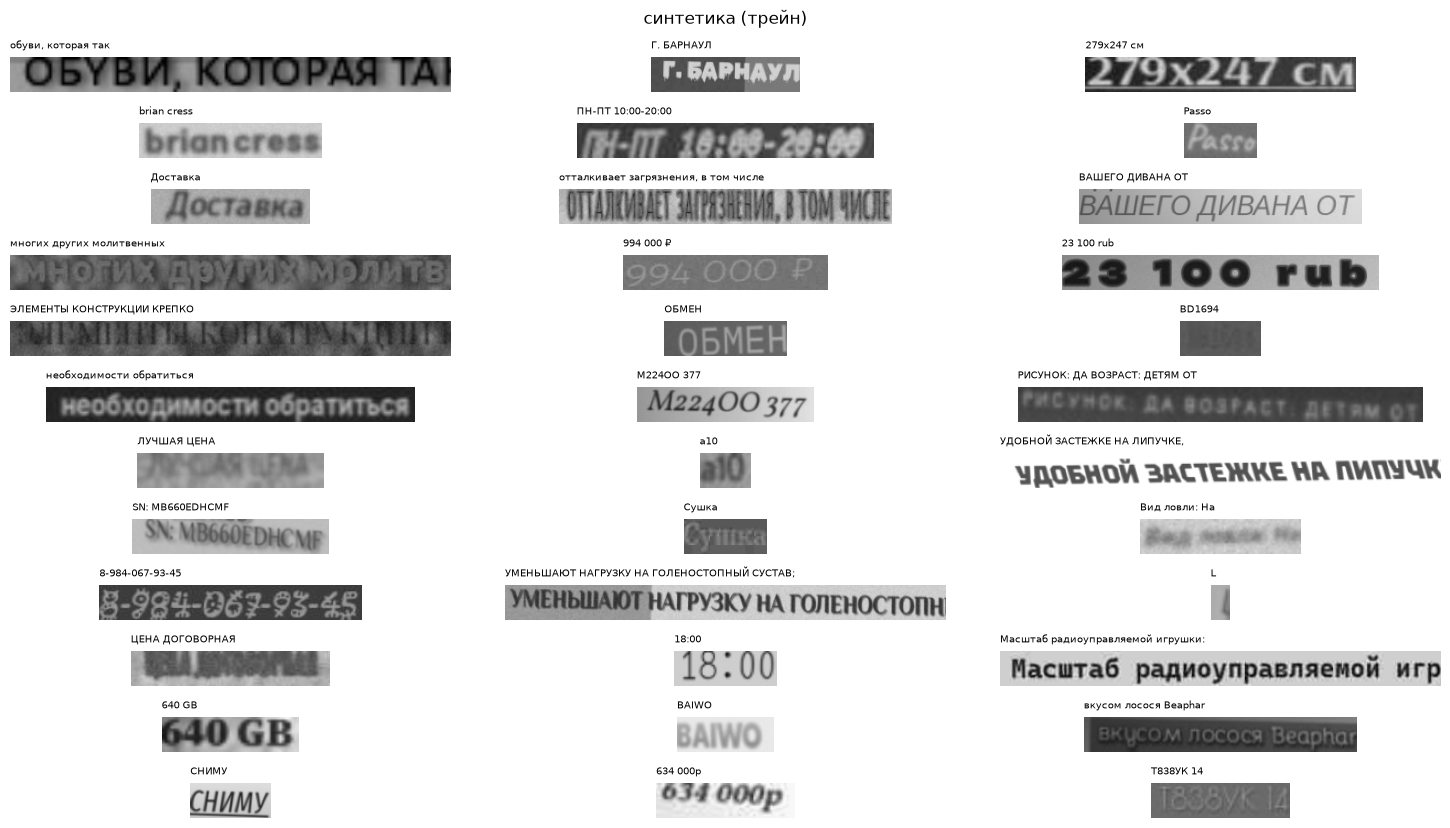

In [2]:
synth = Pack('../data/synth/train.npz')
rng = np.random.RandomState(0)
idx = rng.choice(len(synth), 36, replace=False)
show([synth[i] for i in idx], [synth.extra['texts'][i] for i in idx], title='синтетика (трейн)')

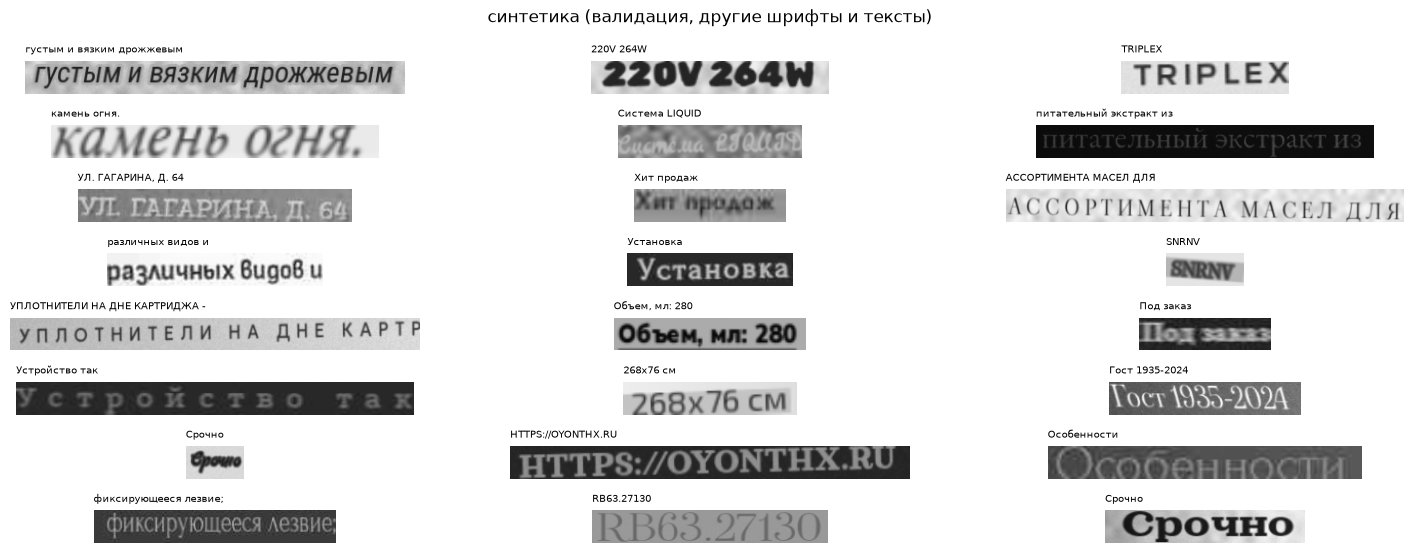

In [3]:
synth_val = Pack('../data/synth/val.npz')
idx = rng.choice(len(synth_val), 24, replace=False)
show([synth_val[i] for i in idx], [synth_val.extra['texts'][i] for i in idx], title='синтетика (валидация, другие шрифты и тексты)')

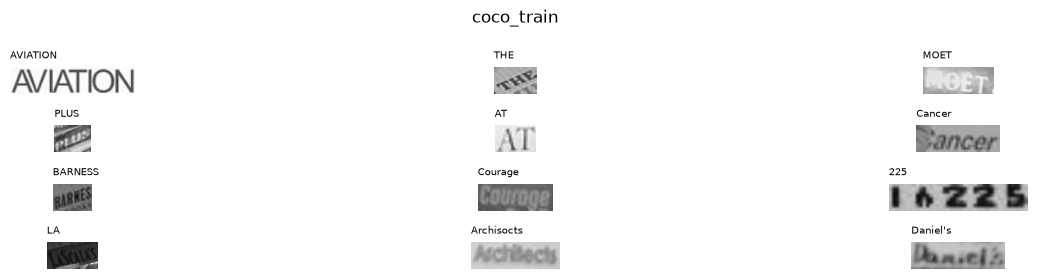

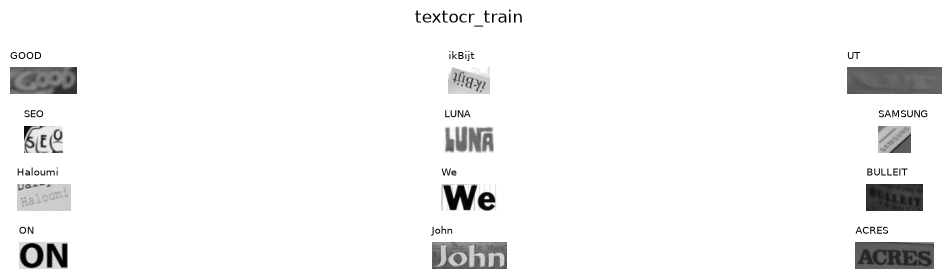

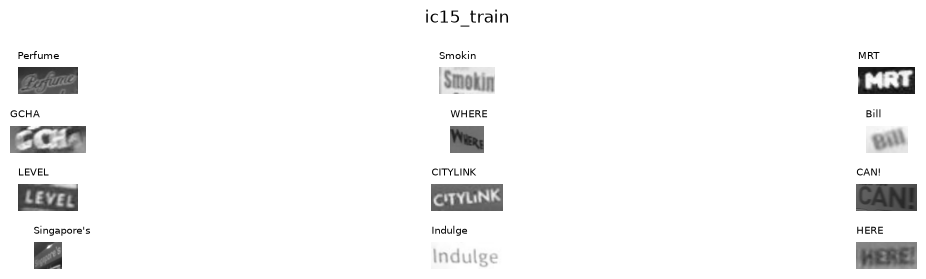

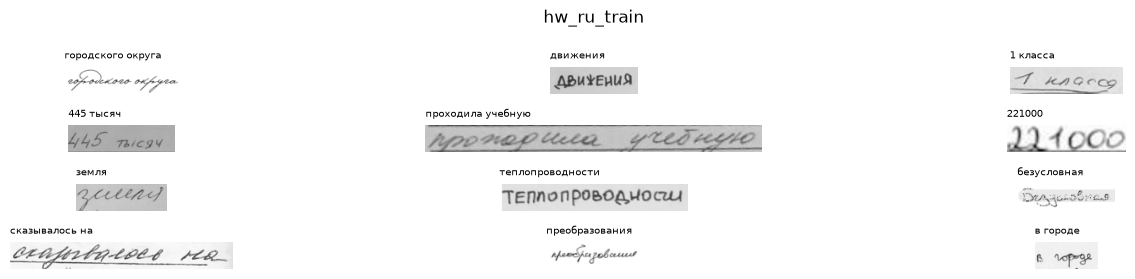

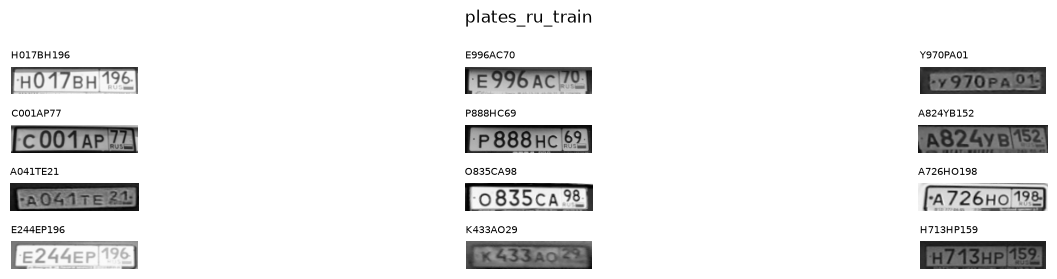

In [4]:
for name in ['coco_train', 'textocr_train', 'ic15_train', 'hw_ru_train', 'plates_ru_train']:
    p = Pack(f'../data/real/{name}.npz')
    idx = rng.choice(len(p), 12, replace=False)
    show([p[i] for i in idx], [p.extra['texts'][i] for i in idx], title=name)

Для сравнения тест после того же препроцессинга (тут примерно половина перевернута):

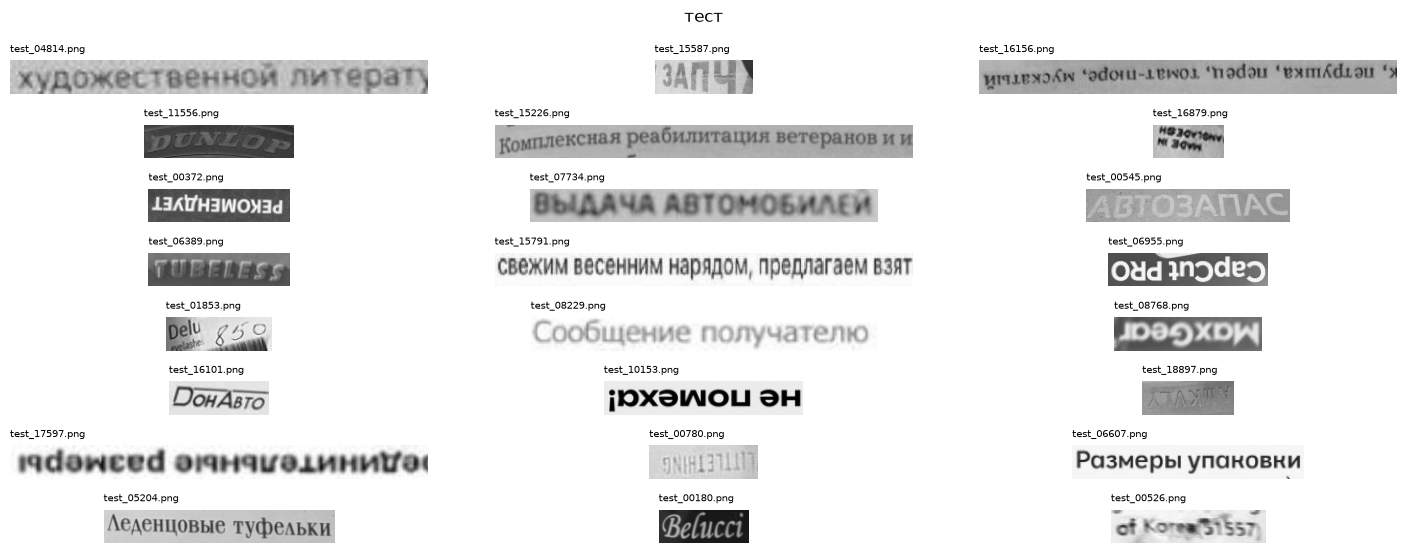

In [5]:
files = sorted(os.listdir('../data/test/images'))
idx = rng.choice(len(files), 24, replace=False)
show([prepare_image(read_image(os.path.join('../data/test/images', files[i]))) for i in idx],
     [files[i] for i in idx], title='тест')

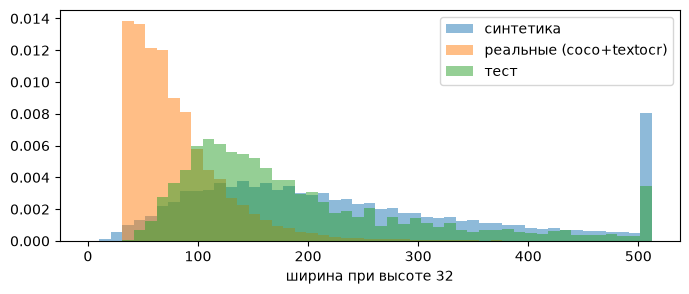

In [6]:
# распределение ширины после препроцессинга: синтетика vs реальные vs тест
test_w = [prepare_image(read_image(os.path.join('../data/test/images', f))).shape[1] for f in files[:3000]]
real_w = np.concatenate([Pack(f'../data/real/{n}.npz').widths for n in ['coco_train', 'textocr_train']])
plt.figure(figsize=(8, 3))
bins = np.linspace(0, 512, 50)
plt.hist(synth.widths, bins=bins, density=True, alpha=0.5, label='синтетика')
plt.hist(real_w, bins=bins, density=True, alpha=0.5, label='реальные (coco+textocr)')
plt.hist(test_w, bins=bins, density=True, alpha=0.5, label='тест')
plt.legend(); plt.xlabel('ширина при высоте 32'); plt.show()

Выводы: синтетика по виду похожа на тест (разные шрифты, фоны, блюр, куски соседних строк),
реальные англ. кропы в основном короткие одиночные слова. По ширине синтетика покрывает и длинные строки, которых в тесте много.